In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math
print("Imports done successfully")

Imports done successfully


In [9]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # STEP 1: Create the Parameters
        # In PyTorch, a Linear layer's weight matrix is shaped (out_features, in_features).
        # Wrap an empty torch.Tensor in nn.Parameter() so the optimizer tracks it.
        
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.gate_scores = nn.Parameter(torch.Tensor(out_features,in_features))
        self.reset_parameters()

    def reset_parameters(self):
        # We initialize the standard weights using Kaiming He initialization
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        
        # STEP 2: The Smart Initialization
        # Use nn.init.constant_ to set every value in self.gate_scores to 2.0
        # (This is our trick to make sure the sigmoid starts at ~0.88 instead of 0.5)
        nn.init.constant_(self.gate_scores,2.0)
        
        # Standard PyTorch bias initialization based on the input size
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        # STEP 3: The Forward Logic
        
        # A. Apply torch.sigmoid() to your gate_scores to crush them between 0 and 1
        gates = torch.sigmoid(self.gate_scores)
        
        # B. Multiply your self.weight by the gates (element-wise, using the * operator)
        pruned_weights = self.weight*gates
        
        # C. Perform the linear operation using F.linear()
        # Pass it your input 'x', your 'pruned_weights', and 'self.bias'
        return F.linear(x,pruned_weights,self.bias)

In [10]:
class SelfPruningMLP(nn.Module):
    def __init__(self):
        super(selfPruningMLP,self).__init__()
        self.layer1=PrunableLinear(3072,512) #defining all layers 3072 represents 32x32x32 3D shape of image 
        self.layer2=PrunableLinear(512,256)
        self.layer3=PrunableLinear(256,10) #since CIFAR 10 dataset contains 10 categories
    
    def forward(self,x):
        x=x.view(x.size(0),-1) #flatening the image from 4D tensor to 2D for neural networks to process it
        x=F.relu(self.layer1(x))
        x=F.relu(self.layer2(x))
        x=self.layer3(x)
        return x
        
    def get_sparsity_loss(self):
        l1_loss=0.0 #intial loss, will update gradually over time during training
        for module in self.modules():
            if isinstance(module,PrunableLinear):#checking whether a the layer is the customized layer or not
                gates=torch.sigmoid(module.gate_scores)
                l1_loss+=torch.sum(gates)
        return l1_loss

In [11]:
def calculate_sparsity(model, threshold=0.01):
    total_gates = 0
    pruned_gates = 0
    with torch.no_grad():
        for module in model.modules(): 
            if isinstance(module, PrunableLinear): 
                gates = torch.sigmoid(module.gate_scores)
                pruned_gates += (gates < threshold).sum().item()
                total_gates += gates.numel() 
    return (pruned_gates / total_gates) * 100

In [12]:
def train_model(target_lambda, trainloader, testloader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = selfPruningMLP().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        current_lambda = target_lambda * min(1.0, (epoch + 1) / 5.0)
        
        for inputs, labels in trainloader:
            # 1. Sending images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 2. Clearing old gradients (PyTorch specific!)
            optimizer.zero_grad()
            
            # 3. Forward pass
            outputs = model(inputs)
            
            # 4. Calculating two losses: sparsity and class loss
            cls_loss = loss_fn(outputs, labels)
            sparsity_loss = model.get_sparsity_loss()
            
            # 5. Combining them using warmed-up lambda
            total_loss = cls_loss + (current_lambda * sparsity_loss)
            
            # 6. Final Backpropagation and performing weight update
            total_loss.backward()
            optimizer.step()
            
    # 7. Evaluation Phase (Outside the epoch loop)
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad(): 
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Get the predicted class
            _, predicted = torch.max(outputs.data, 1) 
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    sparsity = calculate_sparsity(model)
    
    print(f">> Target Lambda: {target_lambda} | Final Accuracy: {accuracy:.2f}% | Final Sparsity: {sparsity:.2f}%")
    return model, accuracy, sparsity

In [13]:
# Prepare the CIFAR-10 data format
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading and Loading CIFAR-10 Data...")

# Load Training Data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

# Load Testing Data
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# Run the Experiment!
lambdas_to_test = [0.0, 0.0001,0.35] 

for l_val in lambdas_to_test:
    trained_model, final_acc, final_spar = train_model(
        target_lambda=l_val, 
        trainloader=trainloader, 
        testloader=testloader, 
        epochs=10
    )

>> Target Lambda: 0.0 | Final Accuracy: 53.69% | Final Sparsity: 0.00%
>> Target Lambda: 0.0001 | Final Accuracy: 57.20% | Final Sparsity: 0.00%
>> Target Lambda: 0.35 | Final Accuracy: 51.21% | Final Sparsity: 0.00%


In [16]:
def plot_gate_histogram(model, target_lambda):
    """Extracts all gate values and plots the required histogram."""
    all_gates = []
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores).cpu().numpy()
                all_gates.extend(gates.flatten())
                
    plt.figure(figsize=(8, 5))
    plt.hist(all_gates, bins=50, color='blue', alpha=0.7)
    plt.title(f'Gate Distribution (Lambda = {target_lambda})')
    plt.xlabel('Gate Value (0 = Pruned, 1 = Active)')
    plt.ylabel('Frequency')
    plt.savefig('gate_distribution.png')
    plt.show()
    plt.close()

def plot_spatial_heatmap(model):
    """The Stand-Out Feature: Visualizes the pruned pixels from Layer 1."""
    with torch.no_grad():
        # Get the gates from the very first layer
        first_layer_gates = torch.sigmoid(model.layer1.gate_scores)
        
        # Average across the 512 output neurons to see overall pixel importance
        pixel_importance = torch.mean(first_layer_gates, dim=0)
        
        # Reshape back to image format: [3 Color Channels, 32 Height, 32 Width]
        pixel_importance = pixel_importance.view(3, 32, 32)
        
        # Average across the 3 RGB channels to get a single 2D heatmap
        spatial_heatmap = torch.mean(pixel_importance, dim=0).cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(spatial_heatmap, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Average Gate Openness (0=Pruned, 1=Kept)')
    plt.title('Spatial Pruning Heatmap (Layer 1)')
    plt.axis('off')
    plt.savefig('spatial_heatmap.png')
    plt.show()
    plt.close()

>> Target Lambda: 0.0 | Final Accuracy: 54.34% | Final Sparsity: 0.00%
>> Target Lambda: 0.0001 | Final Accuracy: 57.54% | Final Sparsity: 0.00%

Generating visual reports for the optimal model...


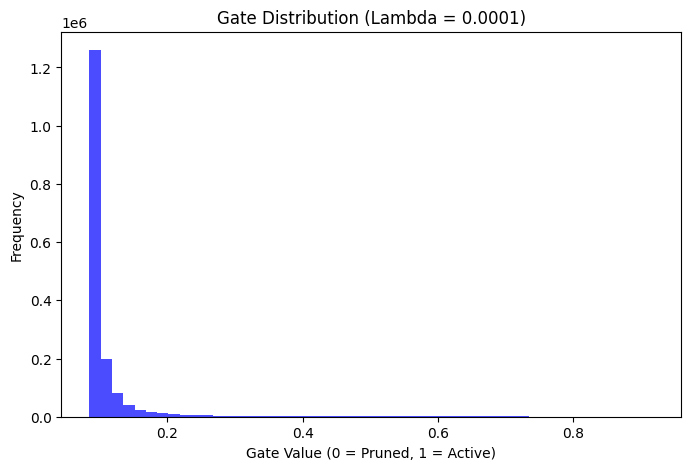

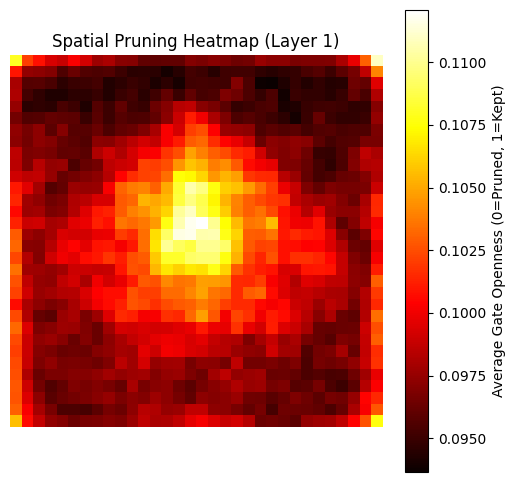

Visualizations saved as 'gate_distribution.png' and 'spatial_heatmap.png'.


In [17]:
# Run the Experiment!
lambdas_to_test = [0.0, 0.0001] 

for l_val in lambdas_to_test:
    trained_model, final_acc, final_spar = train_model(
        target_lambda=l_val, 
        trainloader=trainloader, 
        testloader=testloader, 
        epochs=10
    )
    
    # --- ADDED: Generate visualizations for the optimal model ---
    if l_val == 0.0001:
        print("\nGenerating visual reports for the optimal model...")
        plot_gate_histogram(trained_model, l_val)
        plot_spatial_heatmap(trained_model)
        print("Visualizations saved as 'gate_distribution.png' and 'spatial_heatmap.png'.")